<a href="https://colab.research.google.com/github/alice1702-wq/TimeSeriesAnalysisHW_SpaceMissions/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
!pip install mlforecast neuralforecast statsforecast scipy statsmodels matplotlib scikit-learn pmdarima lightgbm xgboost

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA, AutoETS, Theta
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

import pmdarima as pm
from lightgbm import LGBMRegressor

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from mlforecast.lag_transforms import RollingMean, RollingStd, ExpandingMean
from sklearn.base import BaseEstimator, RegressorMixin

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, TFT, PatchTST

print("Библиотеки успешно загружены!")
import warnings
warnings.filterwarnings('ignore')

Библиотеки успешно загружены!


In [70]:
url = "https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/All%20Space%20Missions%20from%201957/Space_Corrected.csv"
df = pd.read_csv(url, encoding='utf-8', on_bad_lines='skip')

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер данных: (4324, 9)

Первые 5 строк:


,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [71]:
#парсинг дат
def parse_date(date_str):
    try:
        return datetime.strptime(date_str, '%a %b %d, %Y %H:%M UTC')
    except:
        try:
            return datetime.strptime(date_str, '%a %b %d, %Y')
        except:
            return pd.NaT

df['parsed_date'] = df['Datum'].apply(parse_date)
df_clean = df.dropna(subset=['parsed_date']).copy()
df_clean['year'] = df_clean['parsed_date'].dt.year
df_clean['month'] = df_clean['parsed_date'].dt.month

#данные по месяцам
monthly_counts = df_clean.groupby(['year', 'month']).size().reset_index(name='count')
monthly_counts['date'] = pd.to_datetime(monthly_counts[['year', 'month']].assign(day=1))
monthly_counts = monthly_counts.sort_values('date').reset_index(drop=True)

print("Агрегированные данные по месяцам:")
monthly_counts.head()

Агрегированные данные по месяцам:


,year,month,count,date
0,1957,10,1,1957-10-01
1,1957,11,1,1957-11-01
2,1957,12,1,1957-12-01
3,1958,2,2,1958-02-01
4,1958,3,3,1958-03-01


#1. EDA

In [72]:
print("Среднее =", monthly_counts['count'].mean())
print("Медиана =", monthly_counts['count'].median())
print("Стандартное отклонение =", monthly_counts['count'].std())
print("Минимум =", monthly_counts['count'].min())
print("Максимум =", monthly_counts['count'].max())
print("25-й персентиль =", monthly_counts['count'].quantile(0.25))
print("75-й персентиль =", monthly_counts['count'].quantile(0.75))

Среднее = 5.788487282463186
Медиана = 5.0
Стандартное отклонение = 3.0686036573120963
Минимум = 1
Максимум = 18
25-й персентиль = 4.0
75-й персентиль = 8.0


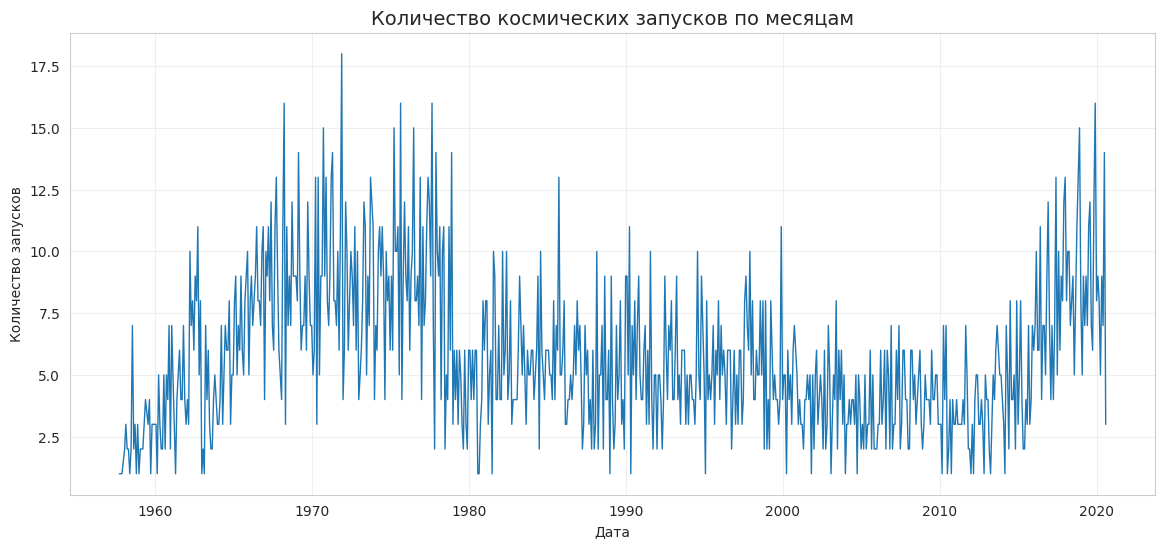

In [73]:
#1. временной ряд
plt.figure(figsize=(14, 6))
plt.plot(monthly_counts['date'], monthly_counts['count'], linewidth=1)
plt.title('Количество космических запусков по месяцам', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество запусков')
plt.grid(True, alpha=0.3)
plt.show()

Основные статистики временного ряда:
count    747.000000
mean       5.788487
std        3.068604
min        1.000000
25%        4.000000
50%        5.000000
75%        8.000000
max       18.000000
Name: count, dtype: float64

ADF Statistic: -2.4260
p-value: 0.1345
Critical values: {'1%': np.float64(-3.4392782790913206), '5%': np.float64(-2.865480319267325), '10%': np.float64(-2.568868260909806)}
Ряд нестационарен (не отвергаем H0 о наличии единичного корня)


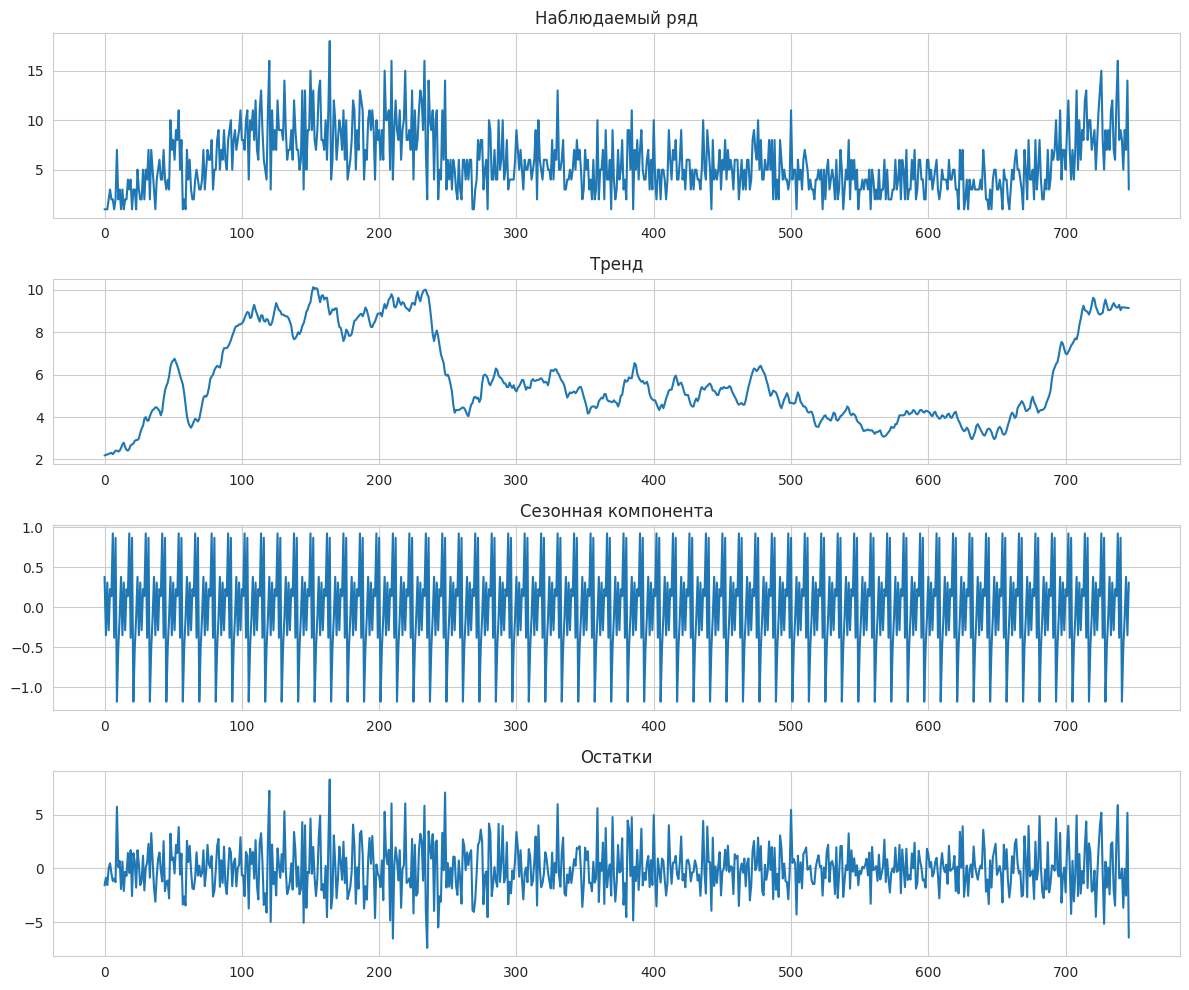

In [74]:
#2. описательная статистика
print("Основные статистики временного ряда:")
print(monthly_counts['count'].describe())

#3. ADF
adf_result = adfuller(monthly_counts['count'], autolag='AIC')
print(f'\nADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print(f'Critical values: {adf_result[4]}')
if adf_result[1] < 0.05:
    print("Ряд стационарен (отвергаем H0 о наличии единичного корня)")
else:
    print("Ряд нестационарен (не отвергаем H0 о наличии единичного корня)")

#4. декомпозиция ряда
decomposition = seasonal_decompose(monthly_counts['count'].values, model='additive', period=12, extrapolate_trend='freq')
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10))
ax1.plot(decomposition.observed)
ax1.set_title('Наблюдаемый ряд')
ax2.plot(decomposition.trend)
ax2.set_title('Тренд')
ax3.plot(decomposition.seasonal)
ax3.set_title('Сезонная компонента')
ax4.plot(decomposition.resid)
ax4.set_title('Остатки')
plt.tight_layout()
plt.show()

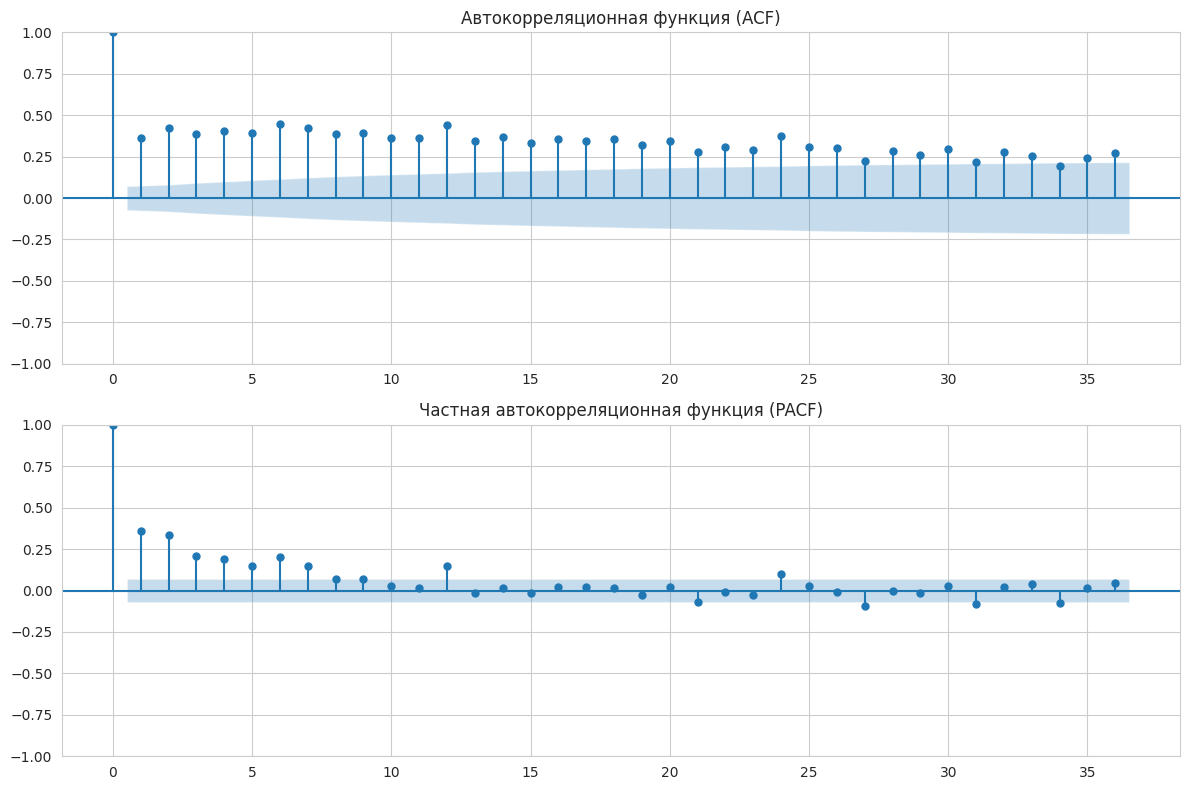

ACF: [1.         0.3623317  0.42330626 0.38569566 0.40322934 0.39309369
 0.44468087 0.42021916 0.3884151  0.39164465 0.36309841]
PACF: [1.         0.3623317  0.33615368 0.21033973 0.19096216 0.15107393
 0.20232462 0.14671996 0.07106103 0.07060584 0.02464565]


In [75]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(monthly_counts['count'], lags=36, ax=ax1, alpha=0.05)
plot_pacf(monthly_counts['count'], lags=36, ax=ax2, method='ywm', alpha=0.05)
ax1.set_title('Автокорреляционная функция (ACF)')
ax2.set_title('Частная автокорреляционная функция (PACF)')
plt.tight_layout()
plt.show()

acf_vals = acf(monthly_counts['count'], nlags=10, fft=False)
pacf_vals = pacf(monthly_counts['count'], nlags=10, method='ywm')
print("ACF:", acf_vals)
print("PACF:", pacf_vals)

In [76]:
monthly_counts.to_csv('monthly_space_missions.csv', index=False)
print("Данные сохранены в monthly_space_missions.csv")

Данные сохранены в monthly_space_missions.csv


# 2. Освоение наиболее популярных инструментов АВР, и обоснованный выбор методов статистических методов анализа ВР

In [77]:
df = pd.read_csv('monthly_space_missions.csv', parse_dates=['date'])
df = df.rename(columns={'date': 'ds', 'count': 'y'})
df['unique_id'] = 'missions'

print("Первые 5 строк данных:")
print(df.head())
print(f"\nРазмер данных: {df.shape[0]} наблюдений")
print(f"Период: {df['ds'].min()} – {df['ds'].max()}")

Первые 5 строк данных:
   year  month  y         ds unique_id
0  1957     10  1 1957-10-01  missions
1  1957     11  1 1957-11-01  missions
2  1957     12  1 1957-12-01  missions
3  1958      2  2 1958-02-01  missions
4  1958      3  3 1958-03-01  missions

Размер данных: 747 наблюдений
Период: 1957-10-01 00:00:00 – 2020-08-01 00:00:00


In [78]:
# модели
models = [
    Naive(),
    SeasonalNaive(season_length=12),
    AutoARIMA(season_length=12, approximation=False, stepwise=True),
    AutoETS(season_length=12, model='ZZZ'),
    Theta(season_length=12)
]

# объект StatsForecast
sf = StatsForecast(
    models=models,
    freq='MS',
    n_jobs=-1
)

print("Модели для сравнения:")
for model in models:
    print(f"  - {model.__class__.__name__}")

Модели для сравнения:
  - Naive
  - SeasonalNaive
  - AutoARIMA
  - AutoETS
  - Theta


In [79]:
# бэктестинг
horizon = 6
test_size = 24
n_windows = 4
step_size = horizon

# кросс-валидация
cv_results = sf.cross_validation(
    df=df,
    h=horizon,
    test_size=test_size,
    n_windows=n_windows,
    step_size=step_size,
    refit=False
)

print("Результаты бэктестинга (первые строки):")
print(cv_results.head())
print(f"\nТестовые периоды: {cv_results['ds'].unique()}")

Результаты бэктестинга (первые строки):
  unique_id         ds     cutoff     y  Naive  SeasonalNaive  AutoARIMA  \
0  missions 2018-09-01 2018-08-01   8.0    5.0            6.0   9.032994   
1  missions 2018-10-01 2018-08-01  11.0    5.0            9.0   8.608298   
2  missions 2018-11-01 2018-08-01  13.0    5.0            8.0   8.840132   
3  missions 2018-12-01 2018-08-01  15.0    5.0           12.0   9.736322   
4  missions 2019-01-01 2018-08-01   8.0    5.0           13.0   8.344940   

    AutoETS     Theta  
0  7.671546  7.875846  
1  8.781487  8.825951  
2  8.217179  8.268274  
3  8.978498  9.121982  
4  7.364164  7.608606  

Тестовые периоды: <DatetimeArray>
['2018-09-01 00:00:00', '2018-10-01 00:00:00', '2018-11-01 00:00:00',
 '2018-12-01 00:00:00', '2019-01-01 00:00:00', '2019-02-01 00:00:00',
 '2019-03-01 00:00:00', '2019-04-01 00:00:00', '2019-05-01 00:00:00',
 '2019-06-01 00:00:00', '2019-07-01 00:00:00', '2019-08-01 00:00:00',
 '2019-09-01 00:00:00', '2019-10-01 00:00:00

In [80]:
# расчёт метрик
def evaluate_cv(cv_df):
    metrics = {}
    model_names = ['Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'Theta']
    for model in model_names:
        if model in cv_df.columns:
            mae = mean_absolute_error(cv_df['y'], cv_df[model])
            rmse = np.sqrt(mean_squared_error(cv_df['y'], cv_df[model]))
            metrics[model] = {'MAE': mae, 'RMSE': rmse}
    return pd.DataFrame(metrics).T

cv_metrics = evaluate_cv(cv_results)
print("Средние метрики по всем окнам:")
print(cv_metrics.round(3))

# Лучшая модель
best_model = cv_metrics['MAE'].idxmin()
print(f"\nЛучшая модель по MAE: {best_model} (MAE = {cv_metrics.loc[best_model, 'MAE']:.3f})")

Средние метрики по всем окнам:
                 MAE   RMSE
Naive          3.958  4.686
SeasonalNaive  2.625  3.434
AutoARIMA      2.529  3.071
AutoETS        2.694  3.338
Theta          2.681  3.321

Лучшая модель по MAE: AutoARIMA (MAE = 2.529)


In [81]:
window_metrics = cv_results.groupby('ds').apply(
    lambda x: pd.Series({
        'Naive_MAE': mean_absolute_error(x['y'], x['Naive']),
        'SeasonalNaive_MAE': mean_absolute_error(x['y'], x['SeasonalNaive']),
        'AutoARIMA_MAE': mean_absolute_error(x['y'], x['AutoARIMA']),
        'ETS_MAE': mean_absolute_error(x['y'], x['AutoETS']),
        'Theta_MAE': mean_absolute_error(x['y'], x['Theta'])
    })
)
print("\nМетрики по отдельным окнам:")
print(window_metrics.round(3))
print(f"\nСтандартное отклонение MAE для AutoARIMA: {window_metrics['AutoARIMA_MAE'].std():.3f}")


Метрики по отдельным окнам:
            Naive_MAE  SeasonalNaive_MAE  AutoARIMA_MAE  ETS_MAE  Theta_MAE
ds                                                                         
2018-09-01        3.0                2.0          1.033    0.328      0.124
2018-10-01        6.0                2.0          2.392    2.219      2.174
2018-11-01        8.0                5.0          4.160    4.783      4.732
2018-12-01       10.0                3.0          5.264    6.022      5.878
2019-01-01        3.0                5.0          0.345    0.636      0.391
2019-02-01        0.0                3.0          2.955    4.125      4.403
2019-03-01        4.0                1.0          0.635    0.974      1.836
2019-04-01        2.0                3.0          1.760    1.205      1.157
2019-05-01        4.0                2.0          0.153    0.427      0.488
2019-06-01        2.0                1.0          2.671    2.596      2.422
2019-07-01        6.0                2.0          1.925    

Данные для графика:
           ds     y  Naive  SeasonalNaive  AutoARIMA  AutoETS  Theta
18 2020-03-01   8.0    9.0            9.0       9.61     8.55   7.58
19 2020-04-01   5.0    9.0            7.0       9.25     8.74   8.59
20 2020-05-01   9.0    9.0            9.0       9.33     9.13   8.99
21 2020-06-01   7.0    9.0            7.0       9.80    10.22   9.91
22 2020-07-01  14.0    9.0           11.0       9.74     8.55   8.64
23 2020-08-01   3.0    9.0           12.0       9.82     9.46   9.80


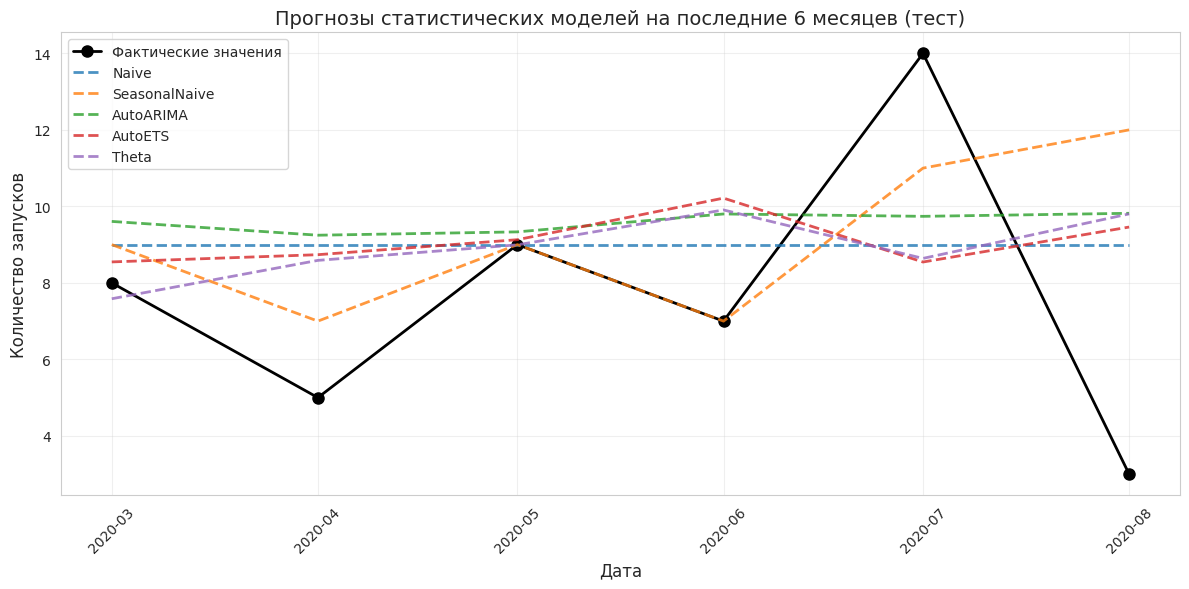

In [82]:
last_6_months = df.iloc[-horizon:].copy()

last_test = cv_results[cv_results['ds'].isin(last_6_months['ds'])].copy()
last_test = last_test.sort_values('ds')

print("Данные для графика:")
print(last_test[['ds', 'y', 'Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'Theta']].round(2))

# график
plt.figure(figsize=(12, 6))

plt.plot(last_test['ds'], last_test['y'], 'o-', label='Фактические значения',
         color='black', linewidth=2, markersize=8)

# прогнозы моделей
plt.plot(last_test['ds'], last_test['Naive'], '--', label='Naive', alpha=0.8, linewidth=2)
plt.plot(last_test['ds'], last_test['SeasonalNaive'], '--', label='SeasonalNaive', alpha=0.8, linewidth=2)
plt.plot(last_test['ds'], last_test['AutoARIMA'], '--', label='AutoARIMA', alpha=0.8, linewidth=2)
plt.plot(last_test['ds'], last_test['AutoETS'], '--', label='AutoETS', alpha=0.8, linewidth=2)
plt.plot(last_test['ds'], last_test['Theta'], '--', label='Theta', alpha=0.8, linewidth=2)

plt.title('Прогнозы статистических моделей на последние 6 месяцев (тест)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество запусков', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('stat_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

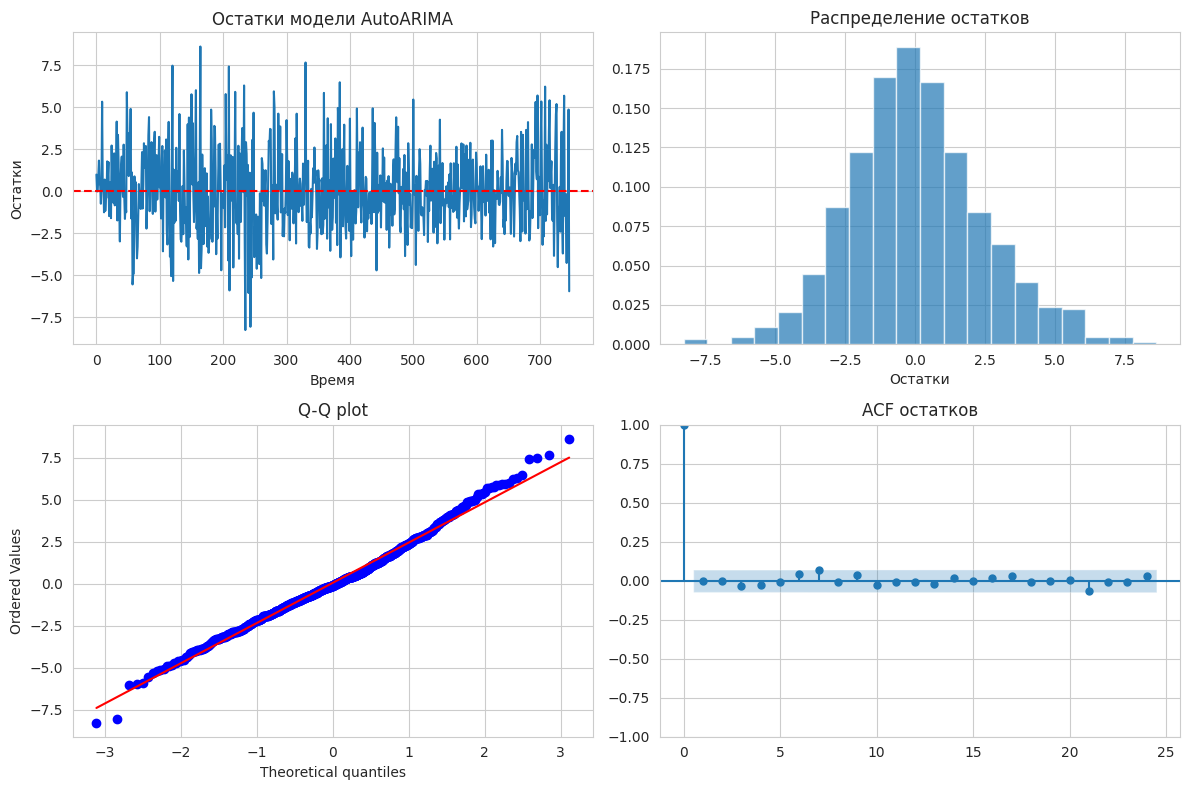

Тест Льюнга-Бокса для остатков AutoARIMA (pmdarima):
      lb_stat  lb_pvalue
12   7.966153    0.78777
24  13.676131    0.95363
Среднее остатков: 0.0643
Стандартное отклонение остатков: 2.3961
Количество остатков: 747


In [83]:
# AutoARIMA через pmdarima
autoarima_pm = pm.auto_arima(
    df['y'].values,
    seasonal=True,
    m=12,
    stepwise=True,
    approximation=False,
    trace=False
)

residuals = autoarima_pm.resid()

# график остатков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# график остатков во времени
axes[0, 0].plot(residuals)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Остатки модели AutoARIMA')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Остатки')

# Гистограмма
axes[0, 1].hist(residuals, bins=20, density=True, alpha=0.7)
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].set_xlabel('Остатки')

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot')

# ACF остатков
plot_acf(residuals, ax=axes[1, 1], lags=24)
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.savefig('autoarima_residuals.png', dpi=150)
plt.show()

# тест Льюнга-Бокса
lb_test = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print("Тест Льюнга-Бокса для остатков AutoARIMA (pmdarima):")
print(lb_test)

print(f"Среднее остатков: {residuals.mean():.4f}")
print(f"Стандартное отклонение остатков: {residuals.std():.4f}")
print(f"Количество остатков: {len(residuals)}")

Прогноз AutoARIMA с 95% ДИ:
2020-09-01: прогноз = 9.08, нижняя граница = 4.39, верхняя граница = 13.78
2020-10-01: прогноз = 8.60, нижняя граница = 3.90, верхняя граница = 13.30
2020-11-01: прогноз = 9.46, нижняя граница = 4.73, верхняя граница = 14.19
2020-12-01: прогноз = 10.65, нижняя граница = 5.90, верхняя граница = 15.40
2021-01-01: прогноз = 8.90, нижняя граница = 4.13, верхняя граница = 13.68
2021-02-01: прогноз = 8.38, нижняя граница = 3.57, верхняя граница = 13.18


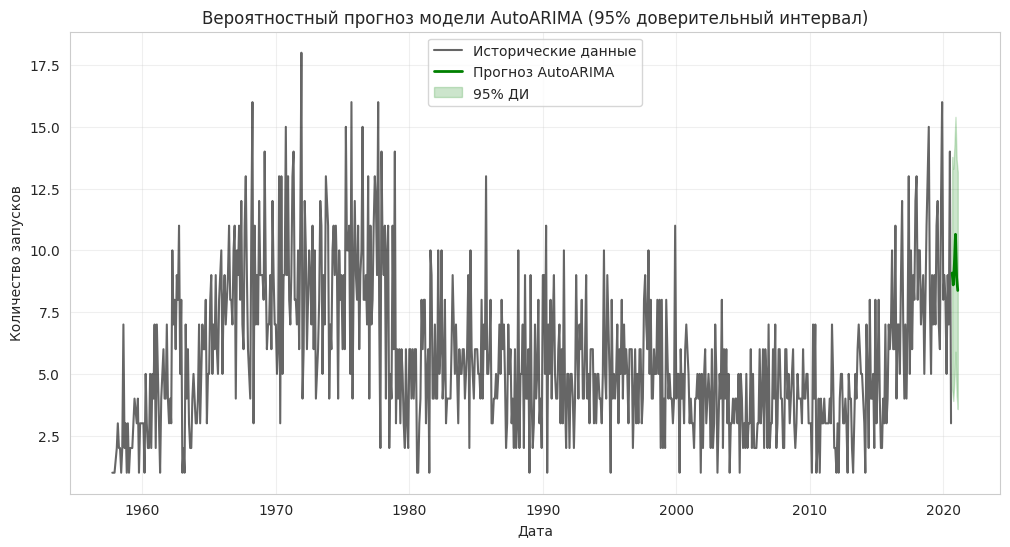

Средняя ширина 95% ДИ: ±4.74 запуска


In [84]:
forecast_result = autoarima_pm.predict(n_periods=horizon, return_conf_int=True)
forecast_mean = forecast_result[0]
conf_int = forecast_result[1]

last_date = df['ds'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=horizon, freq='MS')

print("Прогноз AutoARIMA с 95% ДИ:")
for i, date in enumerate(future_dates):
    print(f"{date.strftime('%Y-%m-%d')}: прогноз = {forecast_mean[i]:.2f}, "
          f"нижняя граница = {conf_int[i, 0]:.2f}, верхняя граница = {conf_int[i, 1]:.2f}")

# визуализация
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'], label='Исторические данные', color='black', alpha=0.6)
plt.plot(future_dates, forecast_mean, 'g-', label='Прогноз AutoARIMA', linewidth=2)
plt.fill_between(future_dates, conf_int[:, 0], conf_int[:, 1],
                 alpha=0.2, color='green', label='95% ДИ')
plt.title('Вероятностный прогноз модели AutoARIMA (95% доверительный интервал)')
plt.xlabel('Дата')
plt.ylabel('Количество запусков')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('autoarima_intervals.png', dpi=150)
plt.show()

# средняя ширина интервала
avg_width = np.mean(conf_int[:, 1] - conf_int[:, 0])
print(f"Средняя ширина 95% ДИ: ±{avg_width/2:.2f} запуска")

In [85]:
print("\n" + "="*60)
print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК (статистические модели)")
print("="*60)
print(cv_metrics.round(3))

best_mae = cv_metrics['MAE'].idxmin()
best_rmse = cv_metrics['RMSE'].idxmin()
print(f"\nЛучшая модель по MAE: {best_mae} (MAE = {cv_metrics.loc[best_mae, 'MAE']:.3f})")
print(f"Лучшая модель по RMSE: {best_rmse} (RMSE = {cv_metrics.loc[best_rmse, 'RMSE']:.3f})")

# расчёт улучшения относительно Naive
naive_mae = cv_metrics.loc['Naive', 'MAE']
best_mae_val = cv_metrics.loc[best_mae, 'MAE']
improvement = (naive_mae - best_mae_val) / naive_mae * 100
print(f"Улучшение {best_mae} относительно Naive: {improvement:.1f}%")

# сравнение с SeasonalNaive
seasonal_mae = cv_metrics.loc['SeasonalNaive', 'MAE']
diff = seasonal_mae - best_mae_val
print(f"Разница между {best_mae} и SeasonalNaive: {diff:.3f} MAE")


ИТОГОВАЯ ТАБЛИЦА МЕТРИК (статистические модели)
                 MAE   RMSE
Naive          3.958  4.686
SeasonalNaive  2.625  3.434
AutoARIMA      2.529  3.071
AutoETS        2.694  3.338
Theta          2.681  3.321

Лучшая модель по MAE: AutoARIMA (MAE = 2.529)
Лучшая модель по RMSE: AutoARIMA (RMSE = 3.071)
Улучшение AutoARIMA относительно Naive: 36.1%
Разница между AutoARIMA и SeasonalNaive: 0.096 MAE


# 3. Обоснованный выбор методов data-driven анализа ВР (ML, DL) и оценка его точности и надежности.

In [86]:
import pandas as pd
import numpy as np
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.lag_transforms import RollingMean, RollingStd, ExpandingMean
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

df = pd.read_csv('monthly_space_missions.csv', parse_dates=['date'])
df = df.rename(columns={'date': 'ds', 'count': 'y'})
df['unique_id'] = 'missions'

full_dates = pd.date_range(start=df['ds'].min(), end=df['ds'].max(), freq='MS')

df_full = df.set_index('ds').reindex(full_dates).reset_index()
df_full = df_full.rename(columns={'index': 'ds'})

df_full['y'] = df_full['y'].fillna(0)
df_full['unique_id'] = df_full['unique_id'].fillna('missions')

print(f"Количество строк после заполнения: {len(df_full)}")
print(f"Пропуски в y: {df_full['y'].isna().sum()}")

df = df_full

# трансформации для создания признаков
lag_transforms = {
    1: [RollingMean(window_size=12), RollingStd(window_size=12)],
    3: [RollingMean(window_size=6)],
    6: [RollingMean(window_size=3)],
    12: [ExpandingMean()],
    24: [ExpandingMean()]
}

# модели
ml_models = {
    'RF': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGB': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=-1)
}

# MLForecast
mlf = MLForecast(
    models=ml_models,
    freq='MS',
    lags=[1, 2, 3, 6, 12, 24],
    lag_transforms=lag_transforms,
    date_features=['month', 'quarter', 'dayofweek'],
    num_threads=6,
    target_transforms=[Differences([12])]
)

mlf.fit(df, static_features=[])

print("ML модели успешно обучены!")

Количество строк после заполнения: 755
Пропуски в y: 0
ML модели успешно обучены!


In [87]:
df_ml_cv = df[['unique_id', 'ds', 'y']].copy()

cv_results_ml = mlf.cross_validation(
    df=df_ml_cv,
    h=horizon,
    n_windows=n_windows,
    step_size=step_size,
    static_features=[]
)

def evaluate_ml_cv(cv_df):
    metrics = {}
    model_names = ['RF', 'XGB', 'LGBM']
    for model in model_names:
        if model in cv_df.columns:
            mae = mean_absolute_error(cv_df['y'], cv_df[model])
            rmse = np.sqrt(mean_squared_error(cv_df['y'], cv_df[model]))
            metrics[model] = {'MAE': mae, 'RMSE': rmse}
    return pd.DataFrame(metrics).T

ml_metrics = evaluate_ml_cv(cv_results_ml)
print("Метрики ML моделей (усреднённые по всем окнам):")
print(ml_metrics.round(3))

best_ml = ml_metrics['MAE'].idxmin()
print(f"\nЛучшая ML модель по MAE: {best_ml} (MAE = {ml_metrics.loc[best_ml, 'MAE']:.3f})")

Метрики ML моделей (усреднённые по всем окнам):
        MAE   RMSE
RF    2.773  3.490
XGB   2.794  3.782
LGBM  2.558  3.382

Лучшая ML модель по MAE: LGBM (MAE = 2.558)


Данные для графика ML:
           ds     y     RF    XGB  LGBM
18 2020-03-01   8.0   9.37   8.28  9.62
19 2020-04-01   5.0   7.03   6.21  5.35
20 2020-05-01   9.0   7.85   7.37  7.45
21 2020-06-01   7.0   8.33   8.22  8.25
22 2020-07-01  14.0   7.14   5.58  6.55
23 2020-08-01   3.0  10.90  12.59  9.68


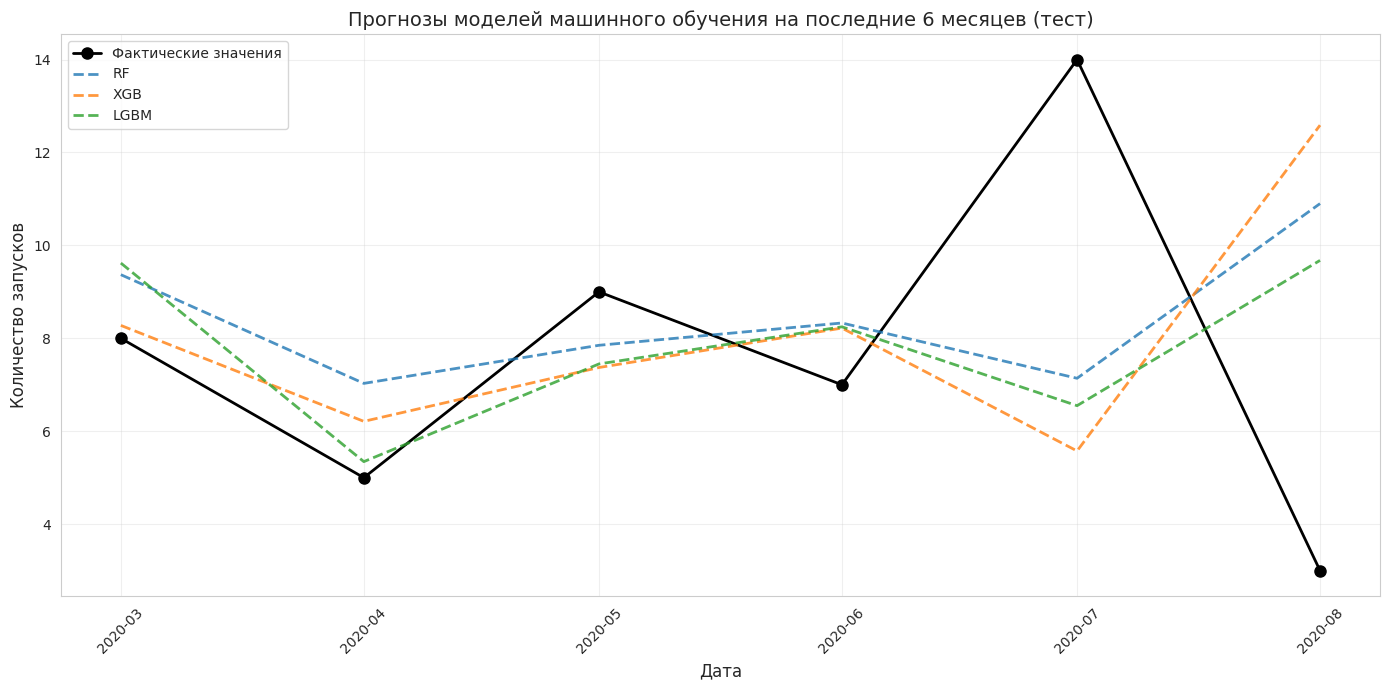

In [88]:
last_6_months_dates = df['ds'].iloc[-horizon:].values
last_test_ml = cv_results_ml[cv_results_ml['ds'].isin(last_6_months_dates)].copy()
last_test_ml = last_test_ml.sort_values('ds')

print("Данные для графика ML:")
print(last_test_ml[['ds', 'y', 'RF', 'XGB', 'LGBM']].round(2))

if len(last_test_ml) == 0:
    print("ВНИМАНИЕ: В cv_results_ml нет прогнозов для последних 6 месяцев.")
    print("Доступные даты в cv_results_ml:", cv_results_ml['ds'].unique()[-10:])
else:
    plt.figure(figsize=(14, 7))
    plt.plot(last_test_ml['ds'], last_test_ml['y'], 'o-', label='Фактические значения',
             color='black', linewidth=2, markersize=8)
    for model in ['RF', 'XGB', 'LGBM']:
        plt.plot(last_test_ml['ds'], last_test_ml[model], '--', label=model, alpha=0.8, linewidth=2)
    plt.title('Прогнозы моделей машинного обучения на последние 6 месяцев (тест)', fontsize=14)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Количество запусков', fontsize=12)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('ml_forecast_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

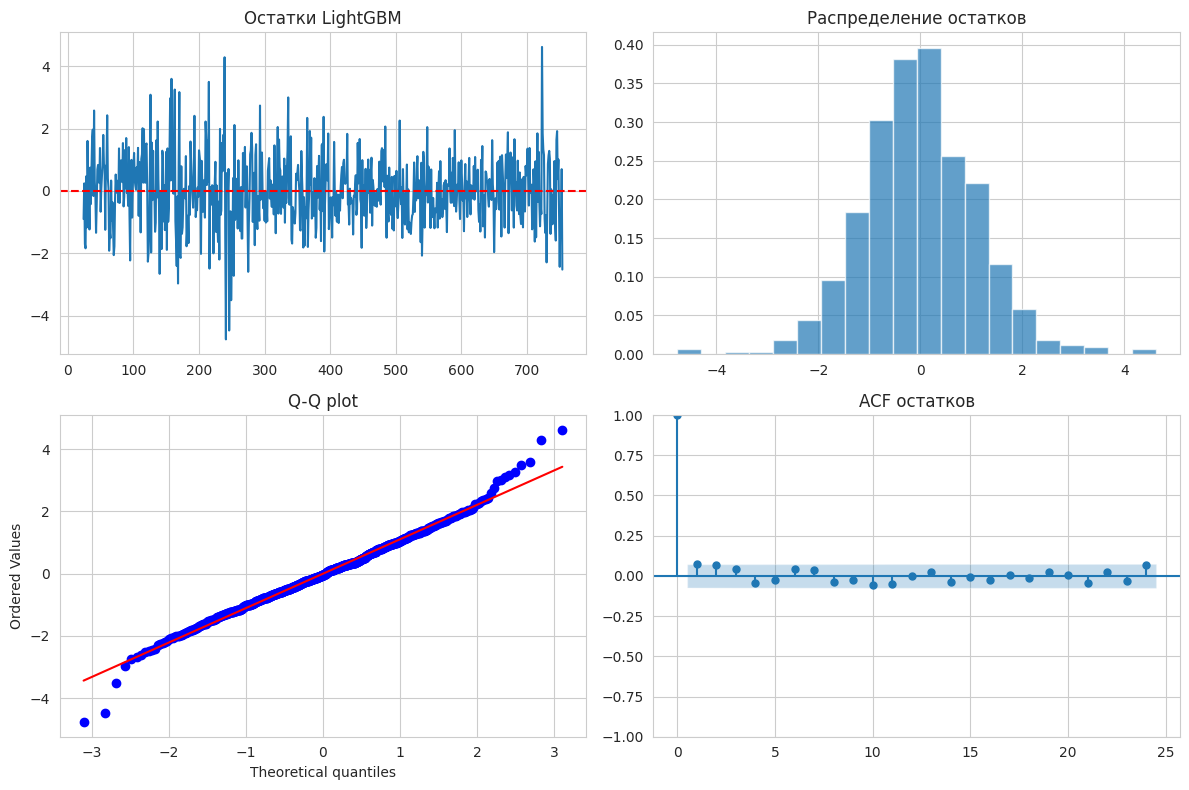

Тест Льюнга-Бокса для остатков LightGBM:
      lb_stat  lb_pvalue
12  18.733681   0.095161
24  27.616478   0.276548
Среднее остатков: -0.0000
Ст. отклонение: 1.1089


In [89]:
X_full = mlf.preprocess(df_nf)

def create_features_lgb(df, lags=[1,2,3,6,12,24]):
    X = pd.DataFrame(index=df.index)
    for lag in lags:
        X[f'lag_{lag}'] = df['y'].shift(lag)
    X['rolling_mean_12'] = df['y'].rolling(12).mean()
    X['month'] = df['ds'].dt.month
    X['quarter'] = df['ds'].dt.quarter
    X['dayofyear'] = df['ds'].dt.dayofyear
    return X.dropna()

X_lgb = create_features_lgb(df_nf)
y_lgb = df_nf.loc[X_lgb.index, 'y']

# LightGBM
lgb_model = LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1)
lgb_model.fit(X_lgb, y_lgb)

y_pred_lgb = lgb_model.predict(X_lgb)
residuals_lgb = y_lgb - y_pred_lgb

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(residuals_lgb); axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Остатки LightGBM')
axes[0, 1].hist(residuals_lgb, bins=20, density=True, alpha=0.7)
axes[0, 1].set_title('Распределение остатков')
stats.probplot(residuals_lgb, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot')
plot_acf(residuals_lgb, ax=axes[1, 1], lags=24)
axes[1, 1].set_title('ACF остатков')
plt.tight_layout()
plt.savefig('lgb_residuals.png', dpi=150)
plt.show()

# тест Льюнга-Бокса
lb_test_lgb = acorr_ljungbox(residuals_lgb, lags=[12, 24], return_df=True)
print("Тест Льюнга-Бокса для остатков LightGBM:")
print(lb_test_lgb)
print(f"Среднее остатков: {residuals_lgb.mean():.4f}")
print(f"Ст. отклонение: {residuals_lgb.std():.4f}")

Прогноз LightGBM с приближёнными интервалами:
           ds  LGBM  lower_80  upper_80  lower_95  upper_95
18 2020-03-01  9.62      5.29     13.95      2.99     16.25
19 2020-04-01  5.35      1.02      9.67     -1.28     11.97
20 2020-05-01  7.45      3.12     11.78      0.82     14.08
21 2020-06-01  8.25      3.92     12.58      1.62     14.88
22 2020-07-01  6.55      2.22     10.88     -0.08     13.18
23 2020-08-01  9.68      5.35     14.01      3.05     16.31


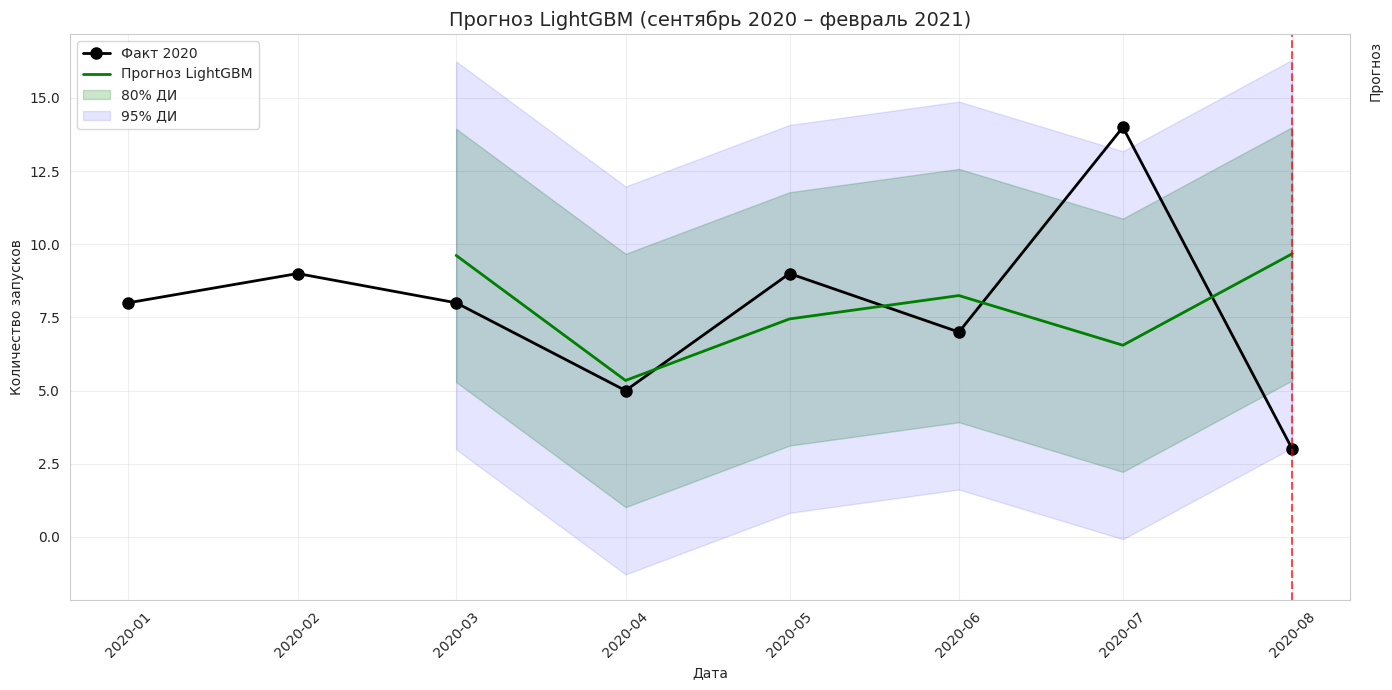

Средняя полуширина 95% ДИ: ±6.63 запуска


In [90]:
rmse_lgb = ml_metrics.loc['LGBM', 'RMSE']

last_6_dates = df['ds'].iloc[-horizon:].values
last_test_lgb = cv_results_ml[cv_results_ml['ds'].isin(last_6_dates)].copy()
last_test_lgb = last_test_lgb.sort_values('ds')

lgb_forecast = last_test_lgb[['ds', 'LGBM']].copy()
lgb_forecast['lower_80'] = lgb_forecast['LGBM'] - 1.28 * rmse_lgb
lgb_forecast['upper_80'] = lgb_forecast['LGBM'] + 1.28 * rmse_lgb
lgb_forecast['lower_95'] = lgb_forecast['LGBM'] - 1.96 * rmse_lgb
lgb_forecast['upper_95'] = lgb_forecast['LGBM'] + 1.96 * rmse_lgb

print("Прогноз LightGBM с приближёнными интервалами:")
print(lgb_forecast.round(2))

actual_2020 = df[df['ds'] >= '2020-01-01'][['ds', 'y']]

plt.figure(figsize=(14, 7))
plt.plot(actual_2020['ds'], actual_2020['y'], 'o-', label='Факт 2020', color='black', linewidth=2, markersize=8)
plt.plot(lgb_forecast['ds'], lgb_forecast['LGBM'], 'g-', label='Прогноз LightGBM', linewidth=2)
plt.fill_between(lgb_forecast['ds'], lgb_forecast['lower_80'], lgb_forecast['upper_80'],
                 alpha=0.2, color='green', label='80% ДИ')
plt.fill_between(lgb_forecast['ds'], lgb_forecast['lower_95'], lgb_forecast['upper_95'],
                 alpha=0.1, color='blue', label='95% ДИ')
plt.axvline(x=pd.Timestamp('2020-08-01'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2020-08-15'), 15, 'Прогноз', rotation=90, fontsize=10)
plt.title('Прогноз LightGBM (сентябрь 2020 – февраль 2021)', fontsize=14)
plt.xlabel('Дата'); plt.ylabel('Количество запусков')
plt.legend(); plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('lgb_intervals.png', dpi=150)
plt.show()

print(f"Средняя полуширина 95% ДИ: ±{1.96 * rmse_lgb:.2f} запуска")

In [91]:
max_epochs = 50
input_size = 24

dl_models = [
    NHITS(h=horizon, input_size=input_size, max_steps=max_epochs,
          early_stop_patience_steps=5, val_check_steps=10, random_seed=42,
          n_freq_downsample=[2, 1, 1]),
    TFT(h=horizon, input_size=input_size, max_steps=max_epochs,
        early_stop_patience_steps=5, val_check_steps=10, random_seed=42),
    PatchTST(h=horizon, input_size=input_size, max_steps=max_epochs,
             early_stop_patience_steps=5, val_check_steps=10, random_seed=42)
]

nf = NeuralForecast(models=dl_models, freq='MS')

df_nf = df[['unique_id', 'ds', 'y']].copy()

nf.fit(df=df_nf, val_size=12)
print("DL модели успешно обучены!")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.739     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=50` reached.


DL модели успешно обучены!


In [92]:
dl_models_no_early = [
    NHITS(h=horizon, input_size=input_size, max_steps=max_epochs,
          random_seed=42, n_freq_downsample=[2, 1, 1]),
    TFT(h=horizon, input_size=input_size, max_steps=max_epochs,
        random_seed=42),
    PatchTST(h=horizon, input_size=input_size, max_steps=max_epochs,
             random_seed=42)
]

nf_no_early = NeuralForecast(models=dl_models_no_early, freq='MS')

cv_results_dl = nf_no_early.cross_validation(
    df=df_nf,
    h=horizon,
    n_windows=n_windows,
    step_size=step_size
)

def evaluate_dl_cv(cv_df):
    metrics = {}
    model_names = ['NHITS', 'TFT', 'PatchTST']
    for model in model_names:
        if model in cv_df.columns:
            mae = mean_absolute_error(cv_df['y'], cv_df[model])
            rmse = np.sqrt(mean_squared_error(cv_df['y'], cv_df[model]))
            metrics[model] = {'MAE': mae, 'RMSE': rmse}
    return pd.DataFrame(metrics).T

dl_metrics = evaluate_dl_cv(cv_results_dl)
print("Метрики DL моделей (усреднённые по всем окнам):")
print(dl_metrics.round(3))

best_dl = dl_metrics['MAE'].idxmin()
print(f"\nЛучшая DL модель по MAE: {best_dl} (MAE = {dl_metrics.loc[best_dl, 'MAE']:.3f})")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.739     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Метрики DL моделей (усреднённые по всем окнам):
           MAE   RMSE
NHITS     2.74  3.354
TFT       2.66  3.382
PatchTST  2.73  3.328

Лучшая DL модель по MAE: TFT (MAE = 2.660)


Данные для графика DL (должно быть 6 строк):
           ds     y  NHITS   TFT  PatchTST
18 2020-03-01   8.0  10.04  9.37      9.66
19 2020-04-01   5.0   9.80  9.31      9.35
20 2020-05-01   9.0   9.56  9.24      8.71
21 2020-06-01   7.0   9.97  9.17      8.84
22 2020-07-01  14.0   9.89  9.12      9.07
23 2020-08-01   3.0   9.72  9.07      9.73


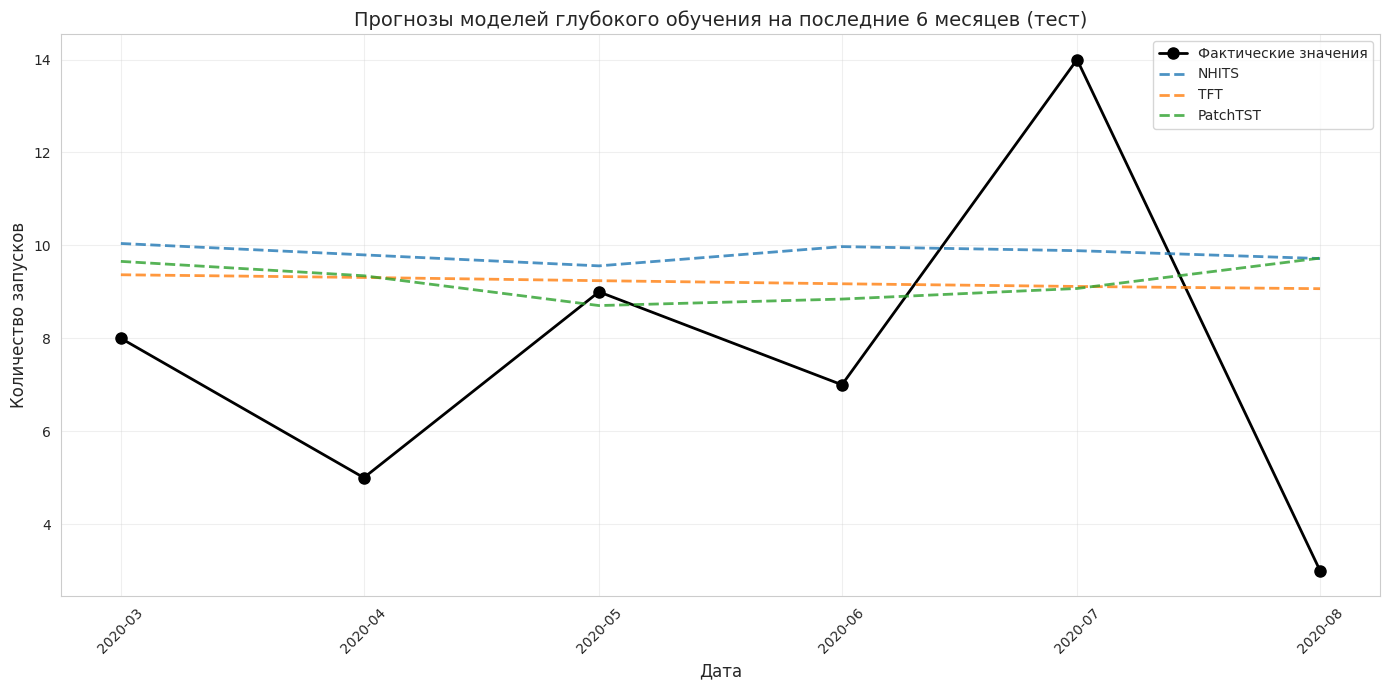

In [93]:
# фильтруем по последним 6 месяцам
last_6_months_dates = df_nf['ds'].iloc[-horizon:].values
last_test_dl = cv_results_dl[cv_results_dl['ds'].isin(last_6_months_dates)].copy()
last_test_dl = last_test_dl.sort_values('ds')

print("Данные для графика DL (должно быть 6 строк):")
print(last_test_dl[['ds', 'y', 'NHITS', 'TFT', 'PatchTST']].round(2))

plt.figure(figsize=(14, 7))
plt.plot(last_test_dl['ds'], last_test_dl['y'], 'o-', label='Фактические значения',
         color='black', linewidth=2, markersize=8)

for model in ['NHITS', 'TFT', 'PatchTST']:
    plt.plot(last_test_dl['ds'], last_test_dl[model], '--', label=model, alpha=0.8, linewidth=2)

plt.title('Прогнозы моделей глубокого обучения на последние 6 месяцев (тест)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество запусков', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dl_forecast_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [94]:
input_size = 36   # 3 года истории
max_steps = 150   # больше эпох
early_stop_patience = 20

tft_improved = TFT(
    h=horizon,
    input_size=input_size,
    max_steps=max_steps,
    early_stop_patience_steps=early_stop_patience,
    val_check_steps=10,
    random_seed=42
)

# NeuralForecast
nf_tft_improved = NeuralForecast(models=[tft_improved], freq='MS')

nf_tft_improved.fit(df=df_nf, val_size=12)

print("Улучшенная TFT обучена!")

forecast_tft_improved = nf_tft_improved.predict()
print("Прогноз улучшенной TFT:")
print(forecast_tft_improved[['ds', 'TFT']].round(2))

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 512    | train
4 | temporal_encoder        | TemporalCovariateEncoder | 613 K  | train
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 256 K  | train
6 | output_adapter          | Linear                   | 129    | train
-----------------------------------------------------------------------------
870 K  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=150` reached.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Улучшенная TFT обучена!


Predicting: |          | 0/? [00:00<?, ?it/s]

Прогноз улучшенной TFT:
          ds   TFT
0 2020-09-01  8.87
1 2020-10-01  8.08
2 2020-11-01  7.72
3 2020-12-01  7.68
4 2021-01-01  7.75
5 2021-02-01  7.82


Predicting: |          | 0/? [00:00<?, ?it/s]

Количество остатков: 755
Среднее остатков: 0.2430
Стандартное отклонение: 2.2925


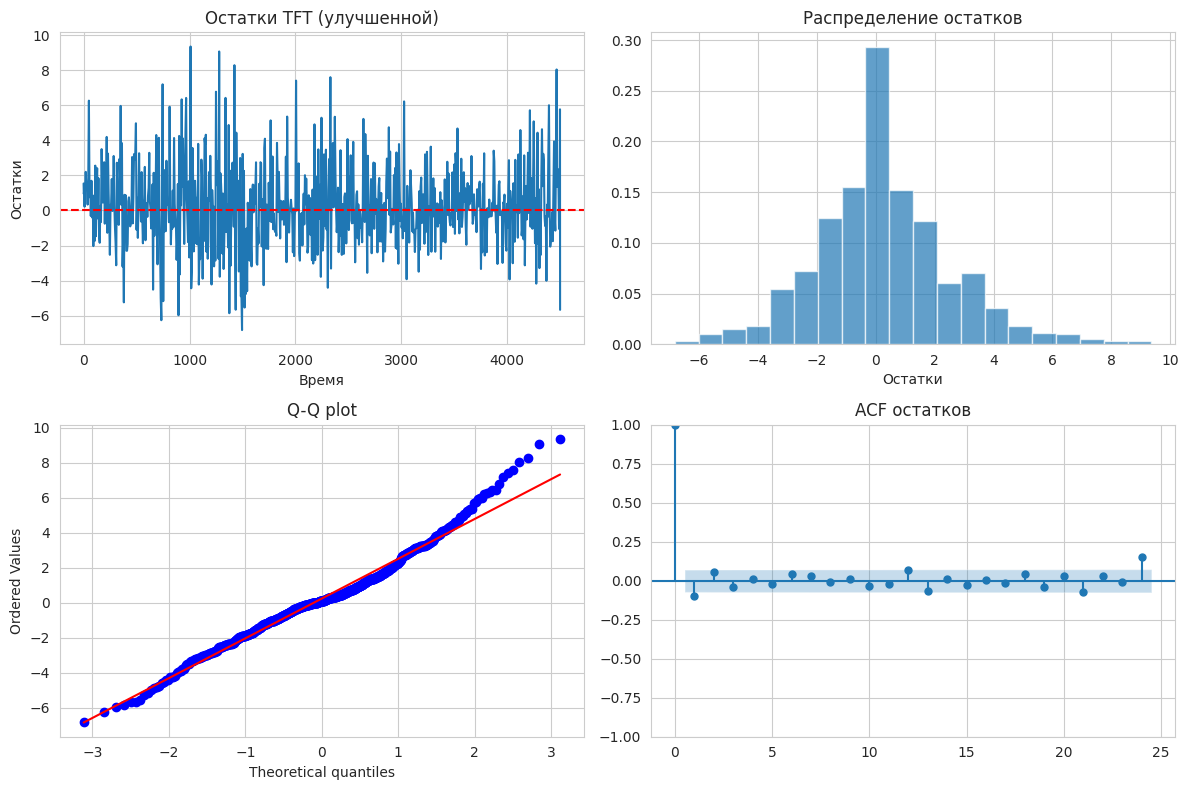

Тест Льюнга-Бокса для остатков TFT (улучшенной):
      lb_stat  lb_pvalue
12  18.426752   0.103334
24  49.633614   0.001576


In [95]:
df_nf = df[['unique_id', 'ds', 'y']].copy()

insample_tft = nf_tft_improved.predict_insample()

insample_merged = df_nf.merge(insample_tft, on=['unique_id', 'ds'], how='left', suffixes=('', '_pred'))

insample_last = insample_merged.loc[
    insample_merged.groupby('ds')['cutoff'].idxmax()
].copy()

residuals_tft = insample_last['y'] - insample_last['TFT']
residuals_tft_clean = residuals_tft.dropna()

print(f"Количество остатков: {len(residuals_tft_clean)}")
print(f"Среднее остатков: {residuals_tft_clean.mean():.4f}")
print(f"Стандартное отклонение: {residuals_tft_clean.std():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(residuals_tft_clean)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Остатки TFT (улучшенной)')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Остатки')

axes[0, 1].hist(residuals_tft_clean, bins=20, density=True, alpha=0.7)
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].set_xlabel('Остатки')

stats.probplot(residuals_tft_clean, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot')

plot_acf(residuals_tft_clean, ax=axes[1, 1], lags=24)
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.savefig('tft_improved_residuals.png', dpi=150)
plt.show()

# тест Льюнга-Бокса
lb_test_tft = acorr_ljungbox(residuals_tft_clean, lags=[12, 24], return_df=True)
print("Тест Льюнга-Бокса для остатков TFT (улучшенной):")
print(lb_test_tft)

Predicting: |          | 0/? [00:00<?, ?it/s]

Прогноз TFT с приближёнными интервалами:
          ds   TFT  lower_80  upper_80  lower_95  upper_95
0 2020-09-01  8.87      4.54     13.20      2.24     15.50
1 2020-10-01  8.08      3.75     12.41      1.45     14.71
2 2020-11-01  7.72      3.39     12.05      1.09     14.35
3 2020-12-01  7.68      3.35     12.01      1.05     14.31
4 2021-01-01  7.75      3.42     12.08      1.12     14.38
5 2021-02-01  7.82      3.49     12.15      1.19     14.45


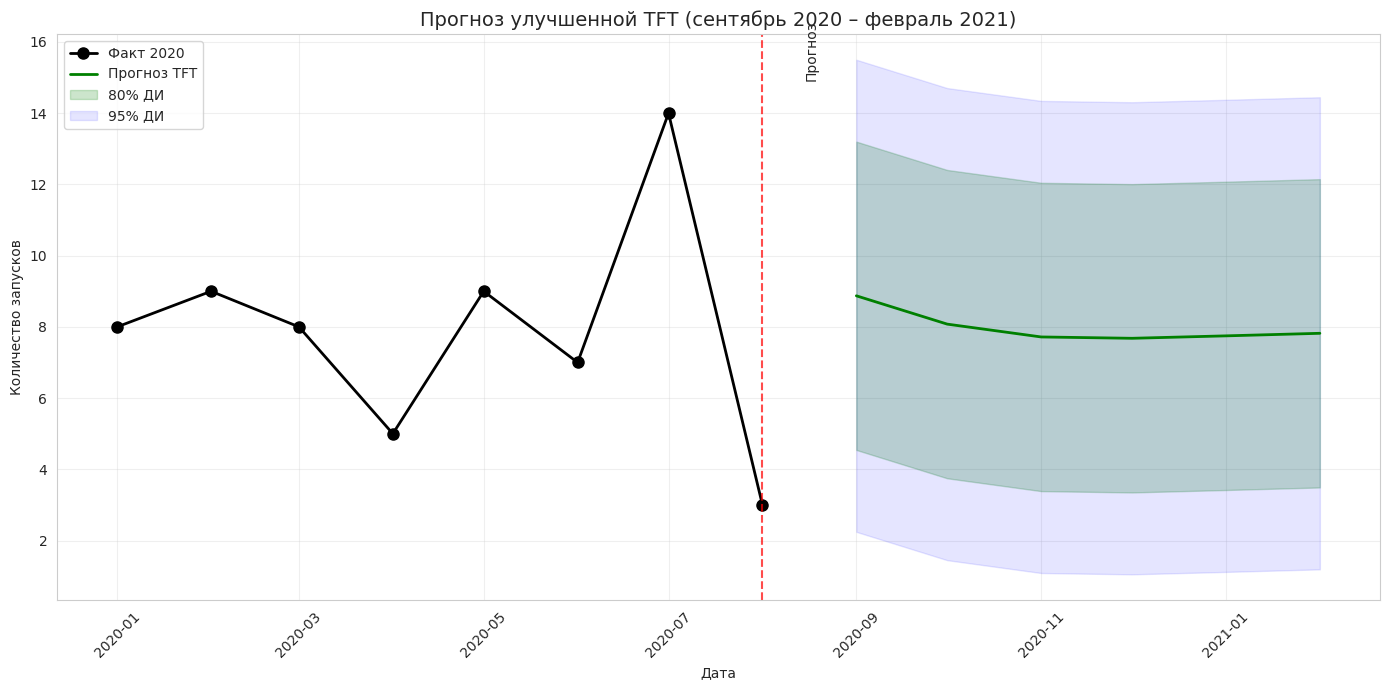

Средняя полуширина 95% ДИ: ±6.63 запуска


In [96]:
rmse_tft = dl_metrics.loc['TFT', 'RMSE']  # 3.382

forecast_tft = nf_tft_improved.predict()
tft_forecast = forecast_tft[['ds', 'TFT']].copy()
tft_forecast['lower_80'] = tft_forecast['TFT'] - 1.28 * rmse_tft
tft_forecast['upper_80'] = tft_forecast['TFT'] + 1.28 * rmse_tft
tft_forecast['lower_95'] = tft_forecast['TFT'] - 1.96 * rmse_tft
tft_forecast['upper_95'] = tft_forecast['TFT'] + 1.96 * rmse_tft

print("Прогноз TFT с приближёнными интервалами:")
print(tft_forecast.round(2))

actual_2020 = df_nf[df_nf['ds'] >= '2020-01-01'][['ds', 'y']]

plt.figure(figsize=(14, 7))
plt.plot(actual_2020['ds'], actual_2020['y'], 'o-', label='Факт 2020', color='black', linewidth=2, markersize=8)
plt.plot(tft_forecast['ds'], tft_forecast['TFT'], 'g-', label='Прогноз TFT', linewidth=2)
plt.fill_between(tft_forecast['ds'], tft_forecast['lower_80'], tft_forecast['upper_80'],
                 alpha=0.2, color='green', label='80% ДИ')
plt.fill_between(tft_forecast['ds'], tft_forecast['lower_95'], tft_forecast['upper_95'],
                 alpha=0.1, color='blue', label='95% ДИ')
plt.axvline(x=pd.Timestamp('2020-08-01'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2020-08-15'), 15, 'Прогноз', rotation=90, fontsize=10)
plt.title('Прогноз улучшенной TFT (сентябрь 2020 – февраль 2021)', fontsize=14)
plt.xlabel('Дата'); plt.ylabel('Количество запусков')
plt.legend(); plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('tft_improved_intervals.png', dpi=150)
plt.show()

print(f"Средняя полуширина 95% ДИ: ±{1.96 * rmse_tft:.2f} запуска")

In [97]:
all_metrics = pd.concat([
    cv_metrics,   # статистические модели (из Задачи №2)
    ml_metrics,   # ML модели
    dl_metrics    # DL модели
])

all_metrics_sorted = all_metrics.sort_values('MAE')

print("\n" + "="*70)
print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК (все модели)")
print("="*70)
print(all_metrics_sorted.round(3))

overall_best = all_metrics_sorted['MAE'].idxmin()
print(f"\nАбсолютный победитель по MAE: {overall_best} (MAE = {all_metrics_sorted.loc[overall_best, 'MAE']:.3f})")

autoarima_mae = cv_metrics.loc['AutoARIMA', 'MAE']
best_mae = all_metrics_sorted.loc[overall_best, 'MAE']
improvement = (autoarima_mae - best_mae) / autoarima_mae * 100
print(f"Улучшение {overall_best} относительно AutoARIMA: {improvement:.1f}%")


ИТОГОВАЯ ТАБЛИЦА МЕТРИК (все модели)
                 MAE   RMSE
AutoARIMA      2.529  3.071
LGBM           2.558  3.382
SeasonalNaive  2.625  3.434
TFT            2.660  3.382
Theta          2.681  3.321
AutoETS        2.694  3.338
PatchTST       2.730  3.328
NHITS          2.740  3.354
RF             2.773  3.490
XGB            2.794  3.782
Naive          3.958  4.686

Абсолютный победитель по MAE: AutoARIMA (MAE = 2.529)
Улучшение AutoARIMA относительно AutoARIMA: 0.0%


# 4. Подготовка пайплайна решения задачи предсказания ВР, а также подготовка отчета исследования ВР.

MAE на тесте (рекурсивный прогноз): 3.600
RMSE на тесте: 4.136


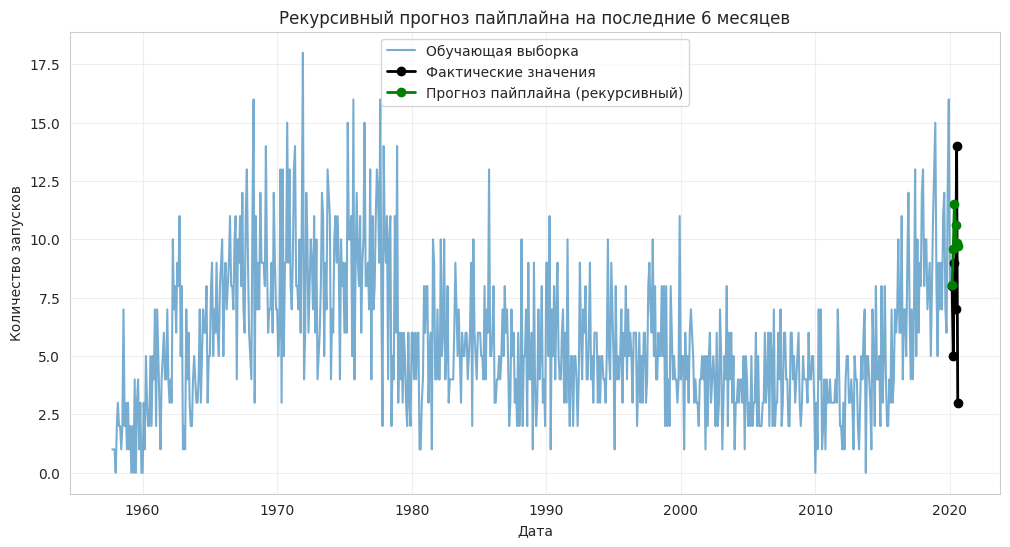

In [98]:
class ForecastingPipeline(BaseEstimator, RegressorMixin):
    def __init__(self, model, lags=[1,2,3,6,12,24], window_features=None):
        self.model = model
        self.lags = lags
        self.window_features = window_features or [('mean12', lambda x: x.rolling(12).mean())]

    def create_features(self, df):
        X = pd.DataFrame(index=df.index)
        for lag in self.lags:
            X[f'lag_{lag}'] = df['y'].shift(lag)
        for name, func in self.window_features:
            X[name] = func(df['y'])
        X['month'] = df['ds'].dt.month
        X['quarter'] = df['ds'].dt.quarter
        X['dayofyear'] = df['ds'].dt.dayofyear
        return X.dropna()

    def fit(self, X, y=None):
        features = self.create_features(X)
        self.model.fit(features, X.loc[features.index, 'y'])
        return self

    def predict(self, X):
        features = self.create_features(X)
        return self.model.predict(features)

def recursive_forecast(pipeline, history, steps):
    """
    history: DataFrame с колонками ds, y (обучающая выборка)
    steps: количество шагов прогноза
    Возвращает список прогнозов на steps шагов вперёд
    """
    hist = history.copy()
    forecasts = []
    for _ in range(steps):
        features = pipeline.create_features(hist)
        last_features = features.iloc[[-1]]
        pred = pipeline.model.predict(last_features)[0]
        new_row = {
            'ds': hist['ds'].iloc[-1] + pd.DateOffset(months=1),
            'y': pred
        }
        hist = pd.concat([hist, pd.DataFrame([new_row])], ignore_index=True)
        forecasts.append(pred)
    return forecasts

horizon = 6
train_data = df.iloc[:-horizon].copy()
test_data = df.iloc[-horizon:].copy()

# пайплайн
pipeline = ForecastingPipeline(
    model=LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1),
    lags=[1, 2, 3, 6, 12, 24]
)

# обучение
pipeline.fit(train_data)


forecast_values = recursive_forecast(pipeline, train_data, horizon)

y_true = test_data['y'].values

mae = mean_absolute_error(y_true, forecast_values)
rmse = np.sqrt(mean_squared_error(y_true, forecast_values))
print(f"MAE на тесте (рекурсивный прогноз): {mae:.3f}")
print(f"RMSE на тесте: {rmse:.3f}")

plt.figure(figsize=(12, 6))
plt.plot(train_data['ds'], train_data['y'], label='Обучающая выборка', alpha=0.6)
plt.plot(test_data['ds'], test_data['y'], 'o-', label='Фактические значения', color='black', linewidth=2)
plt.plot(test_data['ds'], forecast_values, 'o-', label='Прогноз пайплайна (рекурсивный)', color='green', linewidth=2)
plt.title('Рекурсивный прогноз пайплайна на последние 6 месяцев')
plt.xlabel('Дата')
plt.ylabel('Количество запусков')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pipeline_forecast.png', dpi=150)
plt.show()

In [99]:
!jupyter nbconvert --to notebook --clear-output --ClearMetadataPreprocessor.enabled=True --inplace /content/your_notebook_name.ipynb

[NbConvertApp] WARNING | pattern '/content/your_notebook_name.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru